In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression
from matplotlib.colors import TwoSlopeNorm



In [7]:
# ---------- Paths ----------
PATH    = "/Users/kaijz/Desktop/NOAA/data"
RESULTS = "/Users/kaijz/Desktop/NOAA/ensoregimes/ensoregimes/results/figs"

# ---------- Load ----------
df = pd.read_csv(f"{PATH}/daily_dataframe.csv")
df["date"] = pd.to_datetime(df["date"])

# ---------- WR canonical mapping (verified) ----------
WR_NAMES  = {0: "Pacific Trough", 1: "Greenland High", 2: "Pacific Ridge",
             3: "Alaskan Ridge", 4: "No Regime"}
WR_SHORT  = {0: "PT", 1: "GH", 2: "PR", 3: "AR", 4: "N/A"}
WR_COLORS = {0: "#0b6fe2", 1: "#30b430", 2: "#d33131",
             3: "#ddf00a", 4: "#5c676f"}
WR_ORDER  = [0, 2, 3, 1, 4]   # PT, PR, AR, GH, N/A
df["WR_name"] = df["WR"].map(WR_NAMES)

In [8]:
## flavor classification

sigma_E = df["E_index"].std()
sigma_C = df["C_index"].std()
print(f"sigma_E = {sigma_E:.3f},  sigma_C = {sigma_C:.3f}")

def enso_flavor(row, sE=sigma_E, sC=sigma_C):
    E, C = row["E_index"], row["C_index"]
    if abs(E) > sE and abs(E) > abs(C):
        return "E-warm" if E > 0 else "E-cold"
    if abs(C) > sC and abs(E) < sE:
        return "C-warm" if C > 0 else "C-cold"
    return "neutral"

df["flavor"] = df.apply(enso_flavor, axis=1)

sigma_E = 0.959,  sigma_C = 0.949


In [ ]:
FLAVOR_ORDER  = ["E-cold", "C-cold", "neutral", "C-warm", "E-warm"]
FLAVOR_COLORS = {
    "E-cold":  "#08306b",   # deep blue (rare)
    "C-cold":  "#4292c6",   # blue
    "neutral": "#bdbdbd",   # gray
    "C-warm":  "#fb6a4a",   # orange-red
    "E-warm":  "#67000d",   # deep red
}

# RONI-based 5-state strength ordering (for comparison anchor)
RONI_ORDER  = ["strong La Nina", "weak La Nina", "neutral",
               "weak El Nino", "strong El Nino"]
RONI_COLORS = {"strong La Nina": "#2166ac", "weak La Nina": "#92c5de",
               "neutral": "#bdbdbd",
               "weak El Nino": "#f4a582", "strong El Nino": "#b2182b"}

print("\nDaily counts by E/C flavor:")
print(df["flavor"].value_counts().reindex(FLAVOR_ORDER))
print("\nDaily counts by RONI state:")
print(df["RONI_state"].value_counts().reindex(RONI_ORDER))



Daily counts by E/C flavor:
flavor
E-cold      3262
C-cold      5437
neutral    14204
C-warm      1905
E-warm      2932
Name: count, dtype: int64

Daily counts by RONI state:
RONI_state
strong La Nina     2519
weak La Nina       4410
neutral           13631
weak El Nino       4015
strong El Nino     3165
Name: count, dtype: int64


In [10]:
# bootstrapping

def block_bootstrap_freq(sub, wr_order=WR_ORDER, n_boot=500, seed=0):
    """Block bootstrap by year, Returns {wr: (lo95, hi95)} for cond frequency"""
    rng = np.random.default_rng(seed)
    years = sub["year"].unique()
    by_year = {y: sub[sub["year"] == y] for y in years}
    results = {w: [] for w in wr_order}
    for _ in range(n_boot):
        sampled = rng.choice(years, size=len(years), replace=True)
        boot = pd.concat([by_year[y] for y in sampled])
        total = len(boot)
        for w in wr_order:
            results[w].append((boot["WR"] == w).sum() / total * 100
                              if total else np.nan)
    return {w: (np.nanpercentile(results[w], 2.5),
                np.nanpercentile(results[w], 97.5)) for w in wr_order}


In [11]:
# ============================================================
# PLOT 1: WR conditional frequency by ENSO state (single panel)
# ============================================================
def plot_freq_bars(data, state_col, state_order, state_colors,
                   title, ax=None, n_boot=500, show_legend=True,
                   ylim=(0, 35)):
    """Generic conditional frequency bar plot with bootstrap CIs."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    n_states = len(state_order)
    width = 0.8 / n_states
    x = np.arange(len(WR_ORDER))

    for i, state in enumerate(state_order):
        sub = data[data[state_col] == state]
        if len(sub) == 0:
            continue
        vals = [(sub["WR"] == w).sum() / len(sub) * 100 for w in WR_ORDER]
        ci = block_bootstrap_freq(sub, n_boot=n_boot)
        errs = [[vals[k] - ci[w][0] for k, w in enumerate(WR_ORDER)],
                [ci[w][1] - vals[k] for k, w in enumerate(WR_ORDER)]]
        offset = (i - (n_states - 1) / 2) * width
        ax.bar(x + offset, vals, width, yerr=errs, capsize=3,
               color=state_colors[state],
               label=f"{state} (n={len(sub)})",
               edgecolor="k", linewidth=0.4)

    ax.set_xticks(x)
    ax.set_xticklabels([WR_NAMES[w] for w in WR_ORDER], rotation=20)
    ax.set_ylabel("Conditional frequency (%)")
    ax.set_ylim(*ylim)
    ax.grid(axis="y", ls=":", alpha=0.5)
    ax.set_title(title)
    if show_legend:
        ax.legend(title="ENSO state", fontsize=8, loc="upper right")
    return ax

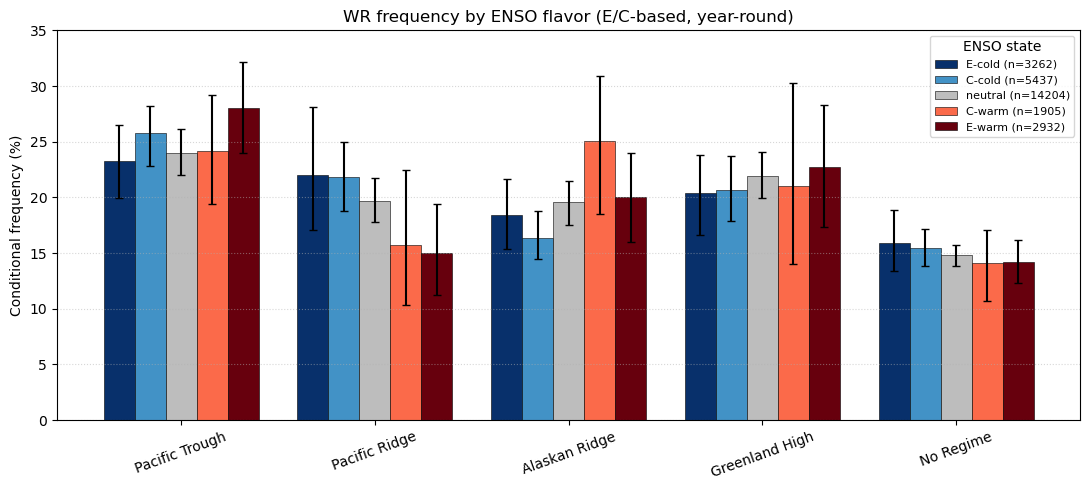

In [ ]:
# 5-flavor E/C classification, year-round
fig, ax = plt.subplots(figsize=(11, 5))
plot_freq_bars(df, "flavor", FLAVOR_ORDER, FLAVOR_COLORS,
               title="WR frequency by ENSO flavor (E/C-based, year-round)",
               ax=ax)
plt.tight_layout()
# plt.savefig(f"{RESULTS}/freq_by_flavor_yearround.png", dpi=140,bbox_inches="tight")
plt.show()

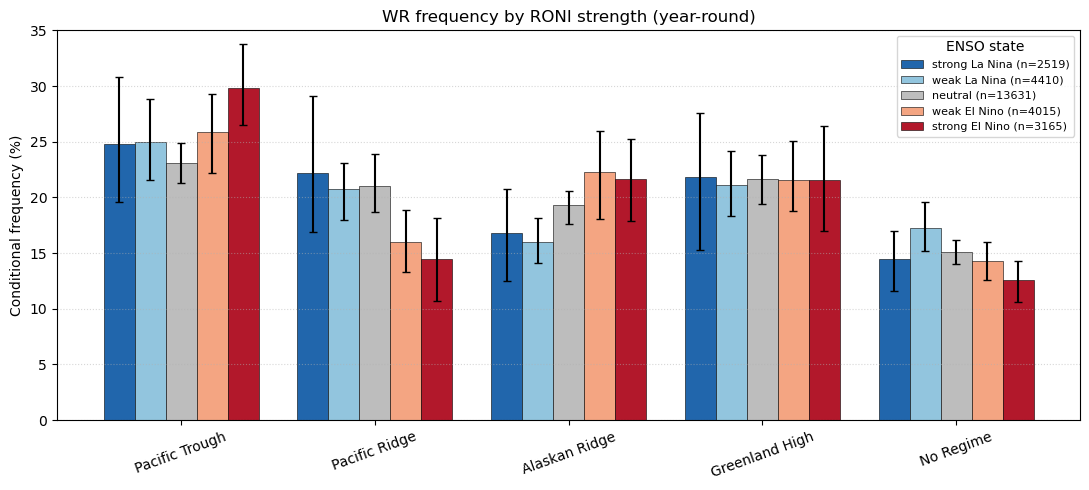

In [ ]:
# comprable RONI-based 5-state version
fig, ax = plt.subplots(figsize=(11, 5))
plot_freq_bars(df, "RONI_state", RONI_ORDER, RONI_COLORS,
               title="WR frequency by RONI strength (year-round)", ax=ax)
plt.tight_layout()
# plt.savefig(f"{RESULTS}/freq_by_RONI_yearround.png", dpi=140 ,bbox_inches="tight")
plt.show()

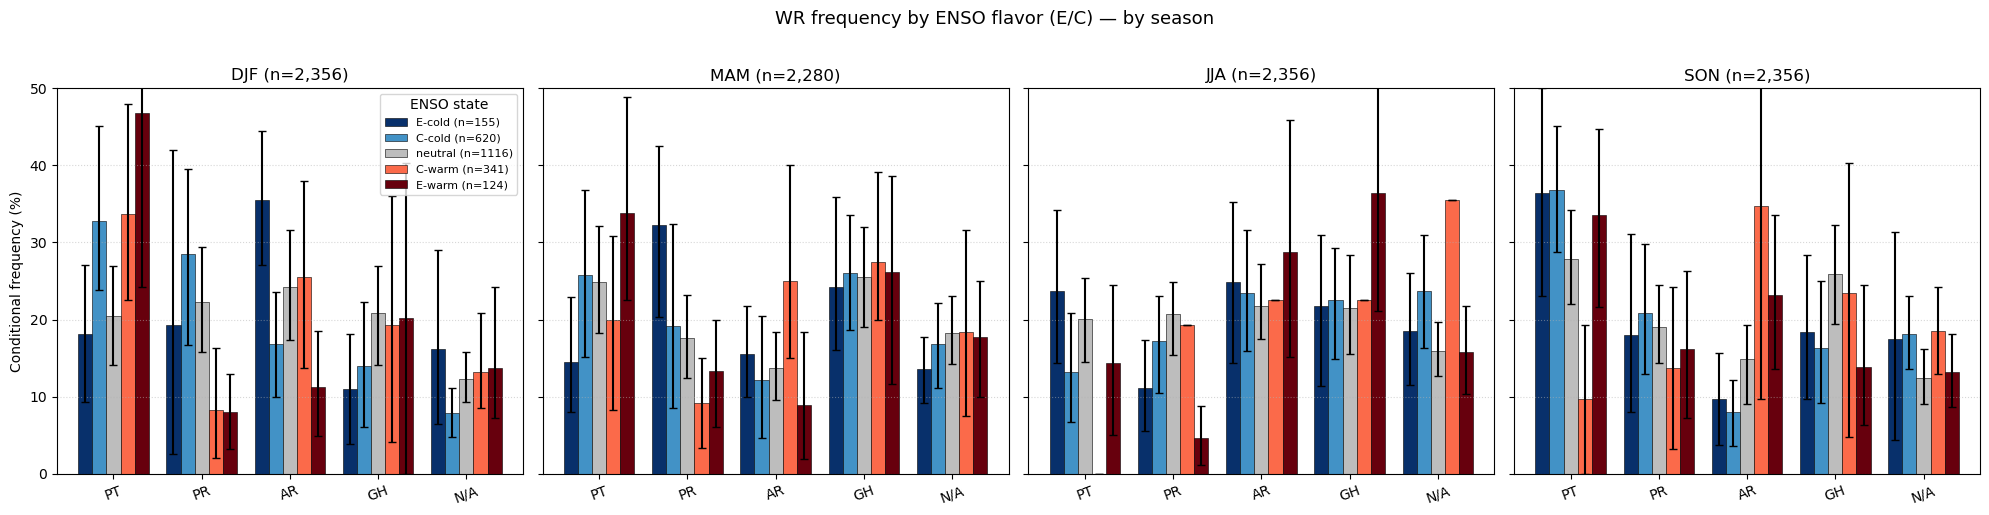

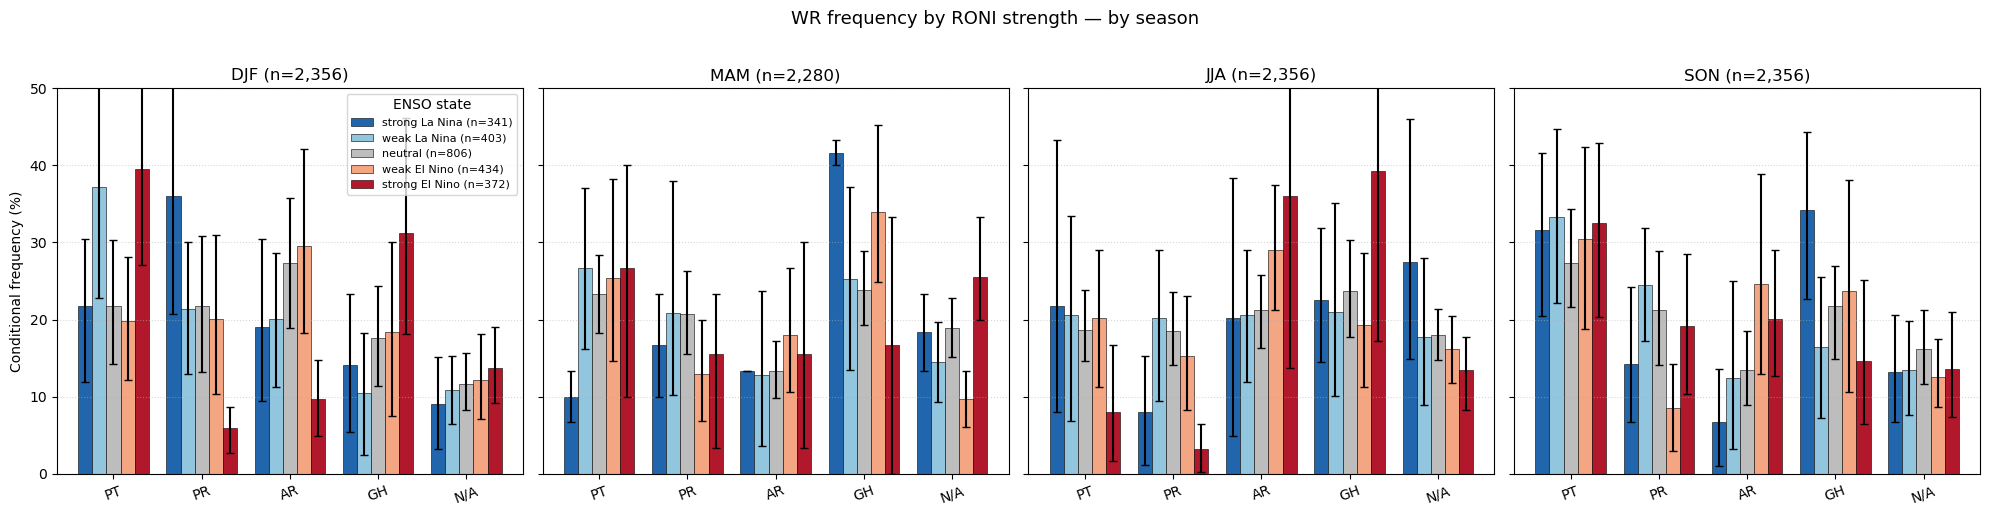

In [23]:
# ============================================================
# PLOT 2: Per-season grid (E/C flavor AND RONI strength)
# ============================================================
def plot_freq_by_season(data, state_col, state_order, state_colors,
                        suptitle, save_name=None, n_boot=300):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
    for ax, season in zip(axes, ["DJF", "MAM", "JJA", "SON"]):
        sub_s = data[data["season"] == season]
        plot_freq_bars(sub_s, state_col, state_order, state_colors,
                       title=f"{season} (n={len(sub_s):,})",
                       ax=ax, n_boot=n_boot,
                       show_legend=(season == "DJF"))
        ax.set_xticklabels([WR_SHORT[w] for w in WR_ORDER])
        ax.set_ylim(0, 50)
        if season != "DJF":
            ax.set_ylabel("")
    plt.suptitle(suptitle, y=1.02, fontsize=13)
    plt.tight_layout()
    if save_name:
        plt.savefig(f"{RESULTS}/{save_name}", dpi=140, bbox_inches="tight")
    plt.show()

plot_freq_by_season(df, "flavor", FLAVOR_ORDER, FLAVOR_COLORS,
                    "WR frequency by ENSO flavor (E/C) — by season",
                    save_name=False) #"freq_by_flavor_by_season.png"

plot_freq_by_season(df, "RONI_state", RONI_ORDER, RONI_COLORS,
                    "WR frequency by RONI strength — by season",
                    save_name=False) #"freq_by_RONI_by_season.png"


In [30]:
# ============================================================
# PLOT 3: (E, C) plane heatmap of WR frequency
# ============================================================
def plot_EC_heatmap(data, season, ax_row, e_bins=None, c_bins=None,
                    min_cell=10, vmax=50, fig=None):
    """Plot 5 panels (one per WR) showing P(WR | E, C) for one season."""
    if e_bins is None:
        e_bins = np.linspace(-3, 3, 13)
    if c_bins is None:
        c_bins = np.linspace(-3, 3, 13)

    sub = data[data["season"] == season]
    h_total, _, _ = np.histogram2d(sub["C_index"], sub["E_index"],
                                   bins=[c_bins, e_bins])

    for col, w in enumerate(WR_ORDER):
        ax = ax_row[col]
        sub_w = sub[sub["WR"] == w]
        h_wr, _, _ = np.histogram2d(sub_w["C_index"], sub_w["E_index"],
                                    bins=[c_bins, e_bins])
        with np.errstate(invalid="ignore", divide="ignore"):
            freq = np.where(h_total >= min_cell,
                            h_wr / h_total * 100, np.nan)
        # Climatological WR frequency for this season - already controlled for
        clim = (sub["WR"] == w).sum() / len(sub) * 100
        # anom = freq - clim   # deviation from climatology
        anom = freq

        vlim = max(20, abs(np.nanmax(anom)) if not np.all(np.isnan(anom)) else 20)
        norm = TwoSlopeNorm(vmin=0, vcenter=vlim/2, vmax=vlim)
        im = ax.pcolormesh(c_bins, e_bins, anom.T, cmap="RdBu_r",
                           norm=norm)
        # 45-degree E and C reference axes (where PC1 and PC2)
        ax.plot([-3, 3], [3, -3], "k--", lw=0.5, alpha=0.4)
        ax.plot([-3, 3], [-3, 3], "k--", lw=0.5, alpha=0.4)
        ax.axhline(0, color="k", lw=0.4); ax.axvline(0, color="k", lw=0.4)
        ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect("equal")
        ax.set_title(f"{WR_NAMES[w]}\n(clim={clim:.1f}%)", fontsize=10)
        if col == 0:
            ax.set_ylabel(f"{season}\nE index")
        ax.set_xlabel("C index")
        if fig is not None and col == len(WR_ORDER) - 1:
            plt.colorbar(im, ax=ax, fraction=0.046,
                         label="freq anomaly (% pts)")
    return im

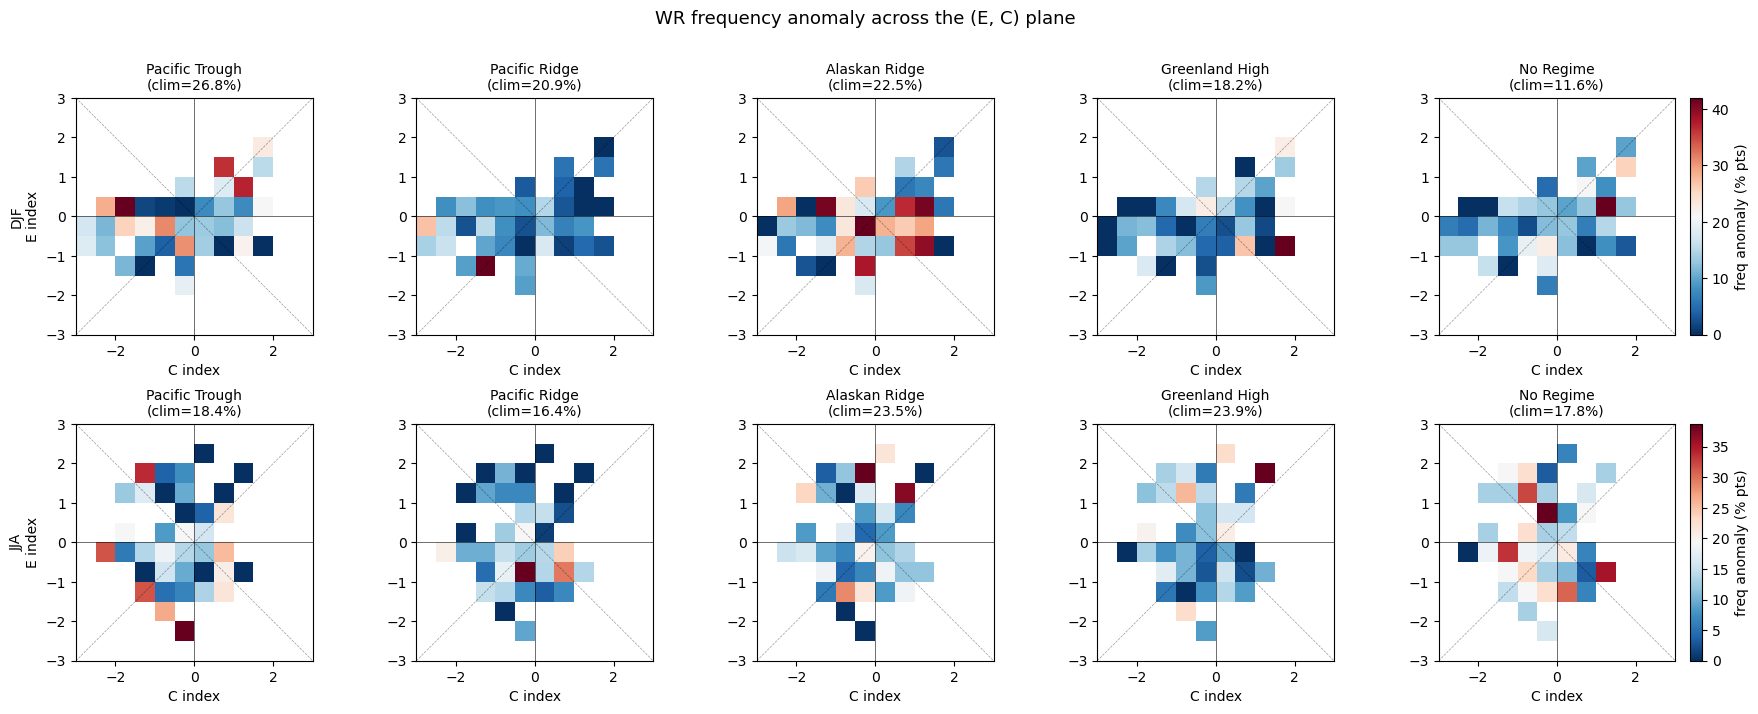

In [31]:

# 2 seasons (DJF and JJA) x 5 WRs
fig, axes = plt.subplots(2, len(WR_ORDER), figsize=(18, 7))
for i, season in enumerate(["DJF", "JJA"]):
    plot_EC_heatmap(df, season, axes[i], fig=fig)
plt.suptitle("WR frequency anomaly across the (E, C) plane",
             y=1.01, fontsize=13)
plt.tight_layout()
# plt.savefig(f"{RESULTS}/EC_heatmap_DJF_JJA.png", dpi=140,bbox_inches="tight")
plt.show()

In [ ]:
'''
rn I have 2 different ways to classify ENSO:
- ONI (using 3-month seasonal 25/75% percentiles) = 3 bins
    La Nina, neutral, El Nino
- RONI (using 0.5) = 5 bins
    neutral, weak La Nina, weak El Nino, strong El Nino, strong La Nina

# here need to add a column splitting these into flavors, was using this but not sure if I should a) depend on RONI or ONI here or b) choose level of detail

plots I would like to have for each:
- 1. histogram this but with E-warm and C-warm separated, also E-cold, C-cold (or whatever I end up splitting the flavors by)
- 2. plot 2 - Lee/Tippett-style figure (your earlier replication) with this new flavor ENSO classification across all four seasons, also with the RONI 5-bin thing. Include block bootstrap CIs.
- 3. the (E, C) heatmap of WR frequency we discussed earlier for each season for DJF and JJA side by side


'''


start_date = '1950-01-01'
end_date = '2025-12-31'

subset_df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

,date,WR,distances,year,month,E_index,C_index,RONI,ONI,season,WR_name,decade,ONI_state,RONI_state
0,1950-01-01,2,71.367786,1950,1,-1.407605,-1.494195,-1.160015,-1.53,DJF,Pacific Ridge,1950,La Nina,strong La Nina
1,1950-01-02,2,69.577674,1950,1,-1.407605,-1.494195,-1.160015,-1.53,DJF,Pacific Ridge,1950,La Nina,strong La Nina
2,1950-01-03,2,67.044385,1950,1,-1.407605,-1.494195,-1.160015,-1.53,DJF,Pacific Ridge,1950,La Nina,strong La Nina
3,1950-01-04,2,64.494670,1950,1,-1.407605,-1.494195,-1.160015,-1.53,DJF,Pacific Ridge,1950,La Nina,strong La Nina
4,1950-01-05,2,62.762696,1950,1,-1.407605,-1.494195,-1.160015,-1.53,DJF,Pacific Ridge,1950,La Nina,strong La Nina
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27735,2025-12-27,4,63.899119,2025,12,-0.788619,-0.270784,-1.030603,-0.54,NDJ,No Regime,2020,neutral,strong La Nina
27736,2025-12-28,1,57.189714,2025,12,-0.788619,-0.270784,-1.030603,-0.54,NDJ,Greenland High,2020,neutral,strong La Nina
27737,2025-12-29,1,48.719027,2025,12,-0.788619,-0.270784,-1.030603,-0.54,NDJ,Greenland High,2020,neutral,strong La Nina
27738,2025-12-30,1,46.044778,2025,12,-0.788619,-0.270784,-1.030603,-0.54,NDJ,Greenland High,2020,neutral,strong La Nina


In [ ]:
# thresholds 1 sigmain either direction

sigma_E = df["E_index"].std()
sigma_C = df["C_index"].std()
print(f"\nsigma_E = {sigma_E},  sigma_C = {sigma_C}")

def enso_state(row, sE=sigma_E, sC=sigma_C):
    E, C = row["E_index"], row["C_index"]
    # E-warm: extreme warm regime, dom E component
    if E > sE and E > abs(C):
        return "E-warm"
    # E-cold (should be rare)
    if E < -sE and abs(E) > abs(C):
        return "E-cold"
    # C-warm: moderate warm in central Pacific
    if C > sC and abs(E) < sE:
        return "C-warm"
    # C-cold: captures La Nina
    if C < -sC and abs(E) < sE:
        return "C-cold"
    return "neutral"

df["enso_state"] = df.apply(enso_state, axis=1)


In [ ]:
state3_order  = ["La Nina", "neutral", "El Nino"]
state3_colors = {"La Nina": "#2c7fb8", "neutral": "#bdbdbd", "El Nino": "#cb181d"}


In [ ]:
# plot 1; histogram splitting by flavor

# 

def block_bootstrap_freq(sub, n_boot=1000, seed=0):
    """Return dict: {wr_val: (lower95, upper95)} for conditional frequency."""
    rng = np.random.default_rng(seed)
    years = sub["year"].unique()
    n_total = len(sub)
    results = {w: [] for w in WR_ORDER}
    # Pre-group by year for fast resampling
    by_year = {y: sub[sub["year"] == y] for y in years}
    for _ in range(n_boot):
        sampled_years = rng.choice(years, size=len(years), replace=True)
        boot = pd.concat([by_year[y] for y in sampled_years])
        total = len(boot)
        for w in WR_ORDER:
            results[w].append((boot["WR"] == w).sum() / total * 100 if total else np.nan)
    return {w: (np.nanpercentile(results[w], 2.5),
                np.nanpercentile(results[w], 97.5)) for w in WR_ORDER}

# this but with separate flavors


fig, ax = plt.subplots(figsize=(10, 5))

freqs, ci_lo, ci_hi = {}, {}, {}
for state in state3_order:
    sub = subset_df[subset_df["ONI_state"] == state]
    freqs[state] = {w: (sub["WR"] == w).sum() / len(sub) * 100 for w in WR_ORDER}
    ci = block_bootstrap_freq(sub, n_boot=500)
    ci_lo[state] = {w: freqs[state][w] - ci[w][0] for w in WR_ORDER}
    ci_hi[state] = {w: ci[w][1] - freqs[state][w] for w in WR_ORDER}

x = np.arange(len(WR_ORDER))
width = 0.27
for i, state in enumerate(state3_order):
    vals = [freqs[state][w] for w in WR_ORDER]
    errs = [[ci_lo[state][w] for w in WR_ORDER],
            [ci_hi[state][w] for w in WR_ORDER]]
    ax.bar(x + (i - 1) * width, vals, width, yerr=errs, capsize=4,
           color=state3_colors[state], label=state, edgecolor="k", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels([WR_NAMES[w] for w in WR_ORDER])
ax.set_ylabel("Conditional frequency (%)")
ax.set_title("WR frequency by ENSO state, year-round\n"
             "(Lee/Tippett-style: 25th/75th RONI percentiles by season)")
ax.legend(title="ENSO state")
ax.set_ylim(0, 35)
ax.grid(axis="y", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()



In [ ]:
# plot 2 - Lee/Tippett-style figure (your earlier replication)
# with 5-state ENSO classification across all four seasons. Include block bootstrap CIs.

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
for ax, season in zip(axes, ["DJF", "MAM", "JJA", "SON"]):
    sub_s = df[df["season"] == season]
    for i, state in enumerate(state3_order):
        sub = sub_s[sub_s["ONI_state"] == state]
        if len(sub) == 0: continue
        vals = [(sub["WR"] == w).sum() / len(sub) * 100 for w in WR_ORDER]
        ci = block_bootstrap_freq(sub, n_boot=300)
        errs = [[vals[k] - ci[w][0] for k, w in enumerate(WR_ORDER)],
                [ci[w][1] - vals[k] for k, w in enumerate(WR_ORDER)]]
        ax.bar(x + (i - 1) * width, vals, width, yerr=errs, capsize=3,
               color=state3_colors[state],
               label=state if season == "DJF" else None,
               edgecolor="k", linewidth=0.4)
    ax.set_xticks(x); ax.set_xticklabels(WR_SHORT.values())
    ax.set_title(f"{season}  (n={len(sub_s):,})")
    ax.grid(axis="y", ls=":", alpha=0.5)
    if season == "DJF":
        ax.set_ylabel("Conditional frequency (%)")
        ax.legend(title="ENSO state", fontsize=8)
plt.suptitle("WR frequency by ENSO state, by season", y=1.02, fontsize=13)
plt.tight_layout()
# plt.savefig(f"{RESULTS}/freq_by_ONI_by_season.png", dpi=140, bbox_inches="tight")
plt.show()

RONI_state
neutral           13631
weak La Nina       4410
weak El Nino       4015
strong El Nino     3165
strong La Nina     2519
Name: count, dtype: int64